In [1]:
#Importo as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carrego os arquivos de dados
dfVendas = pd.read_csv("dfVendas.csv", delimiter= ",")
dfCampanhas = pd.read_csv("campanhas_corrigido.csv", delimiter= ",")

In [3]:
#Realizo o merge entre os dataFrames
dfVendasCampanhas = pd.merge(dfVendas, dfCampanhas, left_on="ID_Campanha", right_on="ID_Campanha", how="inner")
dfVendasCampanhas.head(2)

,ID_Venda,ID_Cliente,ID_Produto,Data,Quantidade,Canal_x,Valor_Total,ID_Campanha,Canal_y,Data_Inicio,Data_Fim,Tipo_Campanha,Custo
0,1,350,45,2022-09-23,4,Online,5795.64,17,Online,2022-07-24,2022-09-29,Desconto,5034.61
1,2,925,68,2024-02-09,1,Loja Física,4614.41,16,Impressos,2024-01-19,2024-03-26,Lançamento,2239.48


In [4]:
dfTotalVendasCampanha = dfVendasCampanhas.groupby("ID_Campanha")["Valor_Total"].sum().reset_index()
dfTotalVendasCampanha

,ID_Campanha,Valor_Total
0,2,10587513.00
1,3,9960534.91
2,4,9788116.49
3,5,10850322.51
4,7,10089807.57
5,8,10581288.50
6,9,9947377.75
7,11,10853593.63
8,12,9530646.41
9,14,9847774.10


In [5]:
#Cria o array com os dados do total de vendas por campanha
arrayTotalVendasCampanha = np.array(dfTotalVendasCampanha["Valor_Total"])
arrayTotalVendasCampanha

array([10587513.  ,  9960534.91,  9788116.49, 10850322.51, 10089807.57,
       10581288.5 ,  9947377.75, 10853593.63,  9530646.41,  9847774.1 ,
       10483962.09,  9261567.66, 10338544.39, 10129802.13,  7273173.97])

In [11]:
#Cálculos estatísticos
media = np.mean(arrayTotalVendasCampanha)
mediana = np.median(arrayTotalVendasCampanha)
q1 = np.percentile(arrayTotalVendasCampanha, 25)
q2 = np.percentile(arrayTotalVendasCampanha, 50)
q3 = np.percentile(arrayTotalVendasCampanha, 75)
distancia = (media - mediana) / mediana
iqr = q3 - q1
limSuperior = q3 + (1.5 * iqr)
limInferior = q1 - (1.5 * iqr)
variancia = np.var(arrayTotalVendasCampanha)
desvio_padrao = np.std(arrayTotalVendasCampanha)
coeficiente_variacao = (desvio_padrao / media) * 100
distancia_variancia = (variancia / (media ** 2)) * 100
minimo = np.min(arrayTotalVendasCampanha)
maximo = np.max(arrayTotalVendasCampanha)
amplitude = maximo - minimo

print(f'Média     = {media:.2f}')
print(f'Mediana   = {mediana:.2f}')
print(f'Q1        = {q1:.2f}')
print(f'Q2        = {q2:.2f}')
print(f'Q3        = {q3:.2f}')
print(f'Distância = {distancia * 100:.2f} %')       #Em percentual
print(f'Lim. Sup. = {limSuperior:.2f}')
print(f'Lim. Inf. = {limInferior:.2f}')
print("Variância:", round(variancia, 2))
print("Desvio padrão:", round(desvio_padrao, 2))
print("Coeficiente de variação:", round(coeficiente_variacao, 2))
print("Distância da variância em relação à média:", round(distancia_variancia, 2))
print(f"Mínimo: {minimo}")
print(f"Máximo: {maximo}")
print(f"Amplitude: {amplitude}")

Média     = 9968268.34
Mediana   = 10089807.57
Q1        = 9817945.29
Q2        = 10089807.57
Q3        = 10532625.29
Distância = -1.20 %
Lim. Sup. = 11604645.29
Lim. Inf. = 8745925.29
Variância: 717795312114.88
Desvio padrão: 847228.02
Coeficiente de variação: 8.5
Distância da variância em relação à média: 0.72
Mínimo: 7273173.97
Máximo: 10853593.63
Amplitude: 3580419.660000001


In [7]:
#Crio um dataFrame com os outliers superiores
dfOutlierSuperior = dfTotalVendasCampanha.loc[dfTotalVendasCampanha["Valor_Total"] >= limSuperior]
dfOutlierSuperior

,ID_Campanha,Valor_Total


In [8]:
#Crio um dataFrame com os valores > q3
dfMaioresQ1 = dfTotalVendasCampanha.loc[dfTotalVendasCampanha["Valor_Total"] >= q3]
dfMaioresQ1 = dfMaioresQ1.sort_values("Valor_Total", ascending=False)
dfMaioresQ1

,ID_Campanha,Valor_Total
7,11,10853593.63
3,5,10850322.51
0,2,10587513.00
5,8,10581288.50


In [10]:
#Crio um dataFrame com os outliers inferiores
dfOutlierInferior = dfTotalVendasCampanha.loc[dfTotalVendasCampanha["Valor_Total"] <= limInferior]
dfOutlierInferior

,ID_Campanha,Valor_Total
14,20,7273173.97


Text(0.5, 1.0, 'BOXPLOT')

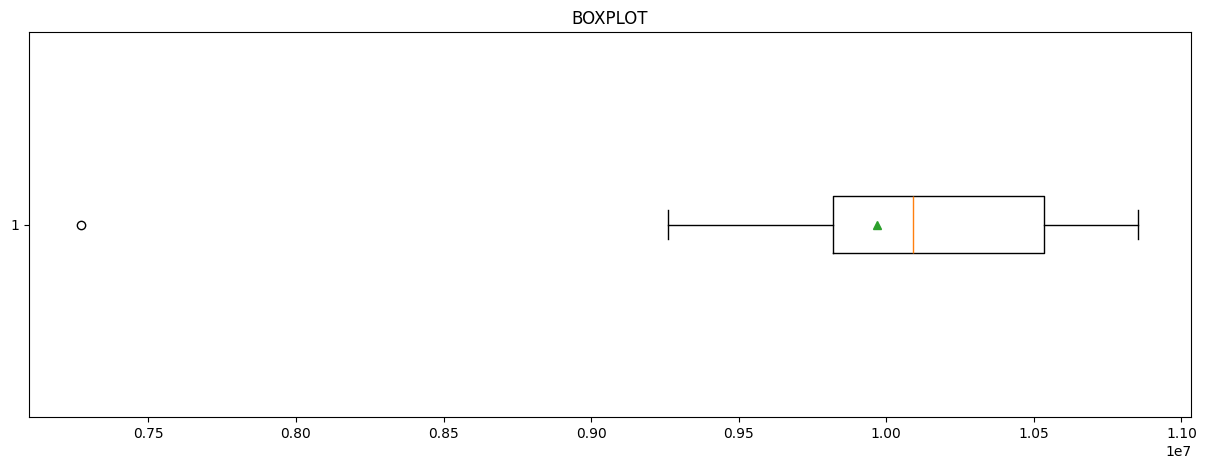

In [9]:
plt.figure(figsize=(15,5))
plt.boxplot(arrayTotalVendasCampanha, vert=False, showmeans=True)
    #showmeans=True (para trazer a média)
    #vert=False (para trazer o gráfico na horizontal)
plt.title('BOXPLOT')